# Install DARTS

### 📈 **Darts: A Modern Time Series Forecasting Library**

Darts is a Python library designed to make time series forecasting and anomaly detection intuitive and powerful. It supports a wide range of models—from classical statistical approaches like ARIMA to cutting-edge deep learning architectures.

🔧 Key Features
- Unified API: All models use fit() and predict() methods, similar to scikit-learn.
- Model Variety: Includes ARIMA, Prophet, RNNs, Transformers, and more.
- Multivariate Support: Handles both univariate and multivariate time series.
- Probabilistic Forecasting: Offers uncertainty estimates for predictions.
- Backtesting & Ensembling: Easily evaluate and combine models.
- External Data Integration: Incorporate covariates and exogenous variables.

🧠 Use Cases
- Demand forecasting
- Predictive maintenance
- Financial time series analysis
- Energy consumption modeling

In [1]:
# ! pip install darts

# Import Other Packages and Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf, month_plot, quarter_plot
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing, Holt
from sklearn.metrics import root_mean_squared_error, mean_squared_error, mean_absolute_error
from darts.timeseries import TimeSeries
from darts.utils.timeseries_generation import datetime_attribute_timeseries
from darts.dataprocessing.transformers import Scaler
from darts.models import RNNModel
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/Time Series Analysis/Python - Time Series Forecasting/Deep Learning for Time Series Forecasting /LSTM/nyc_data.csv',
                 index_col='Date',
                 parse_dates=True)
df.head()

,Demand,Easter,Thanksgiving,Christmas,Temperature,Marketing
Date,,,,,,
2015-01-01,720.000885,0,0,0,3.68,41.305
2015-01-02,581.276773,0,0,0,4.73,131.574
2015-01-03,754.117039,0,0,0,7.23,162.700
2015-01-04,622.252774,0,0,0,10.96,160.281
2015-01-05,785.373319,0,0,0,6.92,51.077


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2192 entries, 2015-01-01 to 2020-12-31
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Demand        2192 non-null   float64
 1   Easter        2192 non-null   int64  
 2   Thanksgiving  2192 non-null   int64  
 3   Christmas     2192 non-null   int64  
 4   Temperature   2192 non-null   float64
 5   Marketing     2192 non-null   float64
dtypes: float64(3), int64(3)
memory usage: 119.9 KB


In [5]:
df = df.asfreq('D')
df.index

DatetimeIndex(['2015-01-01', '2015-01-02', '2015-01-03', '2015-01-04',
               '2015-01-05', '2015-01-06', '2015-01-07', '2015-01-08',
               '2015-01-09', '2015-01-10',
               ...
               '2020-12-22', '2020-12-23', '2020-12-24', '2020-12-25',
               '2020-12-26', '2020-12-27', '2020-12-28', '2020-12-29',
               '2020-12-30', '2020-12-31'],
              dtype='datetime64[ns]', name='Date', length=2192, freq='D')

In [7]:
# Change the target variable column name 'Demand' to 'y'

df = df.rename(columns={'Demand': 'y'})
df.head()

,y,Easter,Thanksgiving,Christmas,Temperature,Marketing
Date,,,,,,
2015-01-01,720.000885,0,0,0,3.68,41.305
2015-01-02,581.276773,0,0,0,4.73,131.574
2015-01-03,754.117039,0,0,0,7.23,162.700
2015-01-04,622.252774,0,0,0,10.96,160.281
2015-01-05,785.373319,0,0,0,6.92,51.077


# EDA

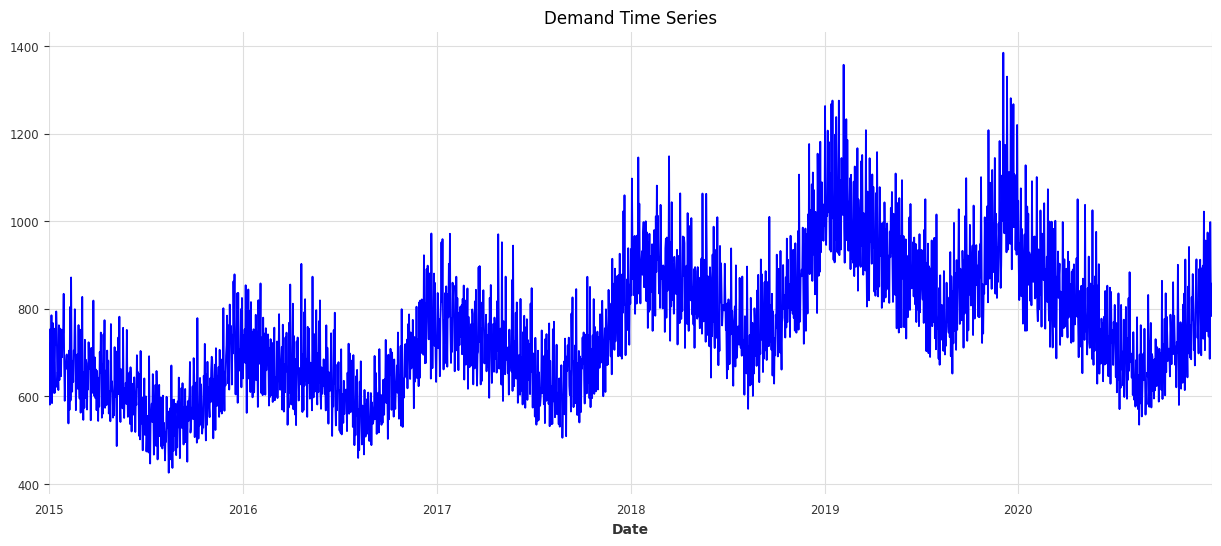

In [11]:
plt.figure(figsize=(15, 6))
df['y'].plot(title = 'Demand Time Series', color='blue')
plt.show()

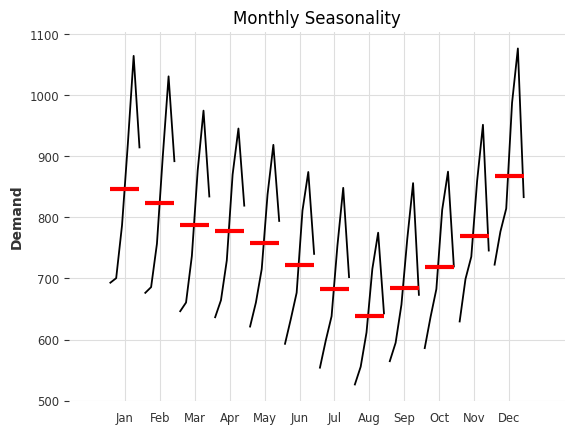

In [14]:
# Monthly Seasonality
month_plot(df['y'].resample('M').mean())
plt.title('Monthly Seasonality')
plt.ylabel('Demand')
plt.show()

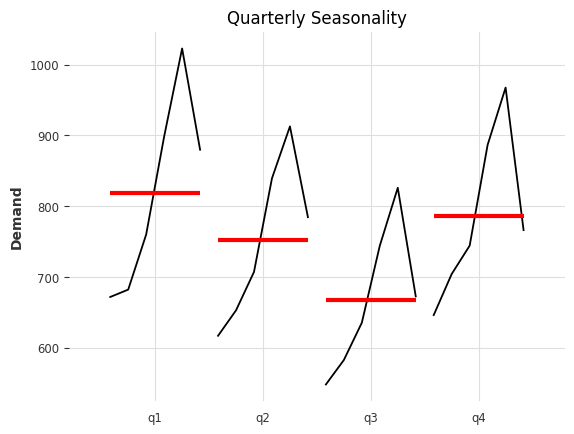

In [15]:
# Quarterly Seasonality

quarter_plot(df['y'].resample('Q').mean())
plt.title('Quarterly Seasonality')
plt.ylabel('Demand')
plt.show()

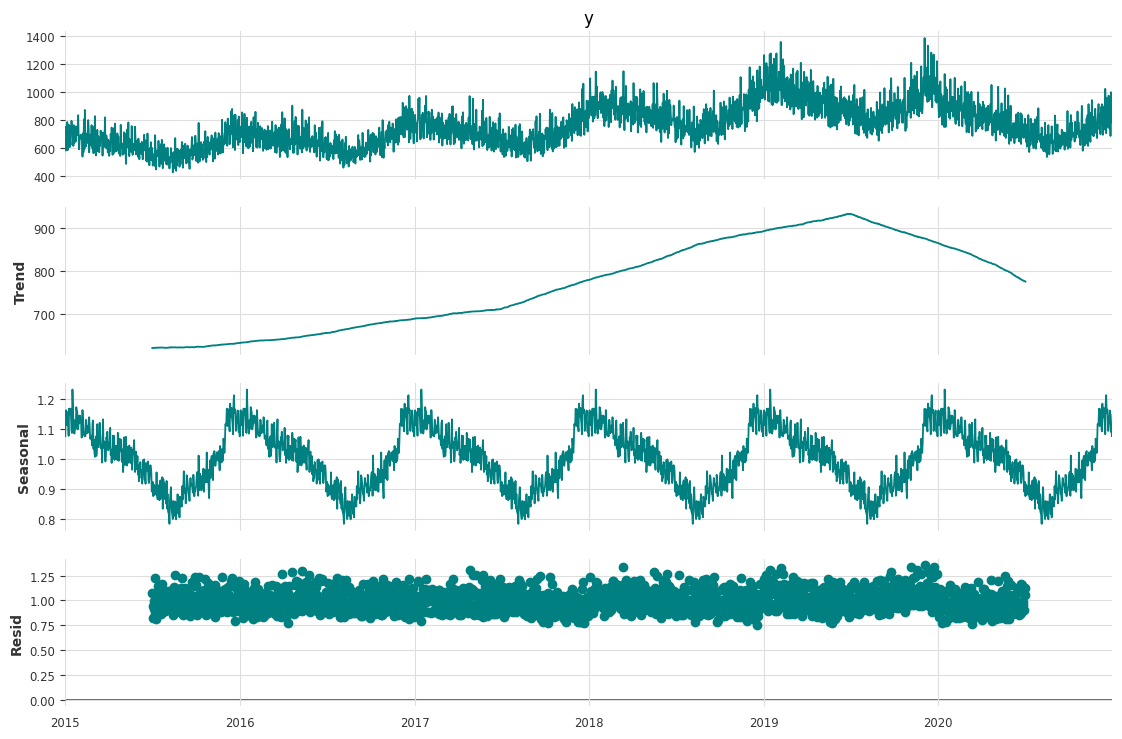

In [32]:
# Seasonal decomposition of 'Demand'  (12 month period, model='additive')

result = seasonal_decompose(df['y'], model='multiplicative', period=365)
fig = result.plot()

# Change line color to blue for all axes
for ax in fig.axes:
    for line in ax.get_lines():
        line.set_color('teal')

# Adjust figure size (if needed)
fig.set_size_inches(12, 8)
plt.show()


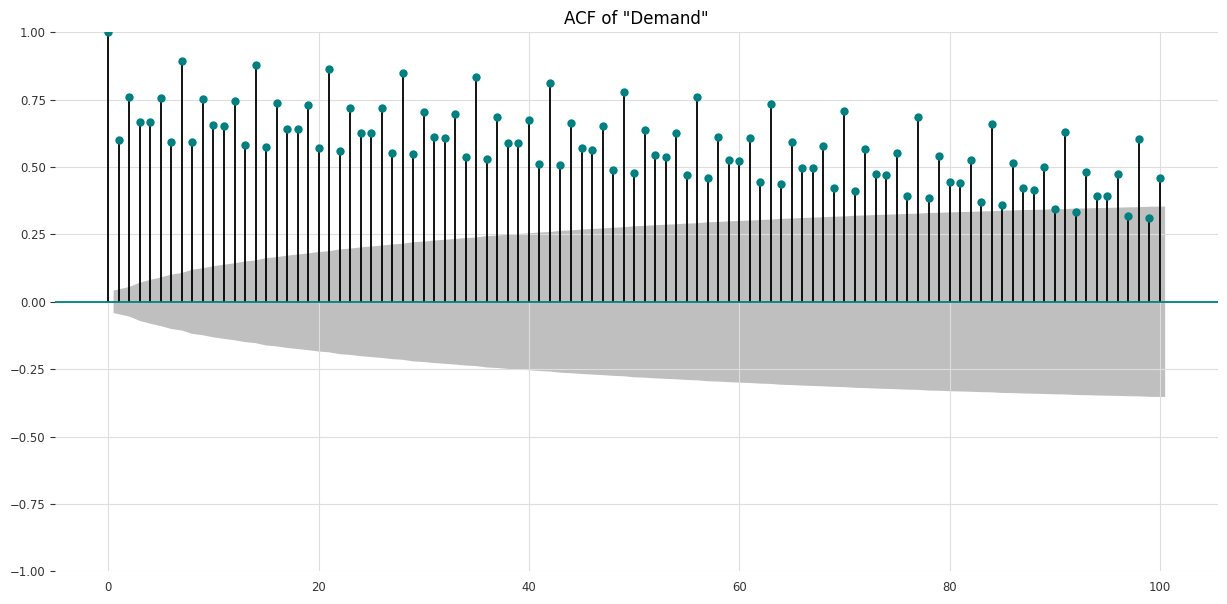

In [33]:
# Plot the ACF for the 'Demand' data
fig, ax = plt.subplots(figsize=(15,7))
plot_acf(df['y'], lags=100, ax=ax, color='teal')
plt.title('ACF of "Demand"')
plt.show()

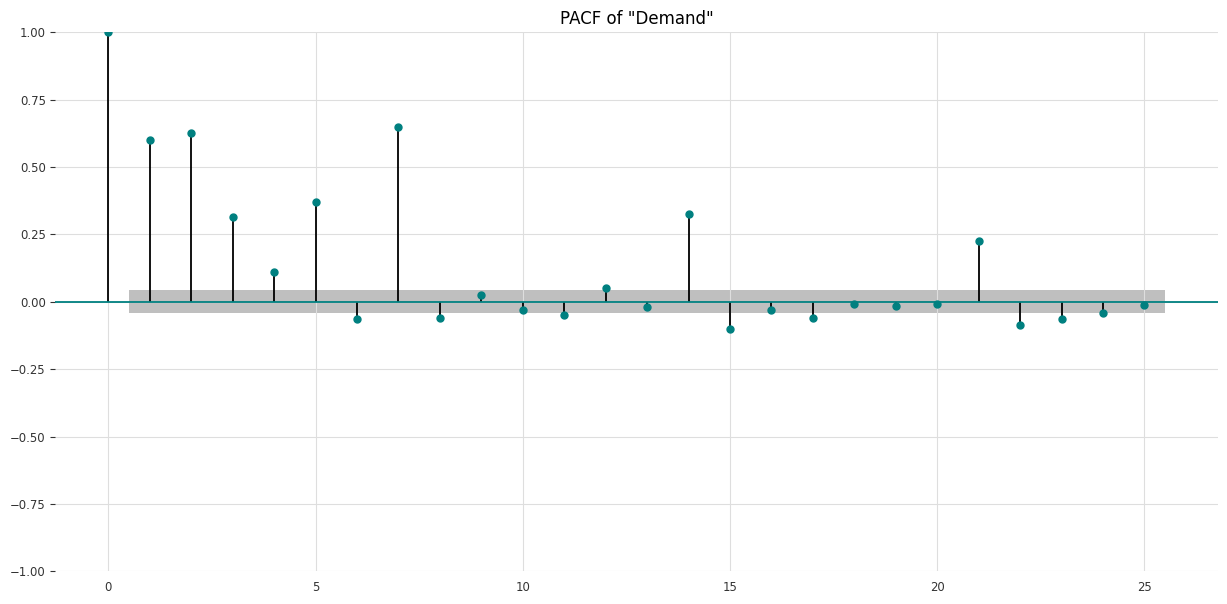

In [36]:
# PACF of 'Demand'
fig, ax = plt.subplots(figsize=(15,7))
plot_pacf(df['y'], lags=25, ax=ax, color='teal')
plt.title('PACF of "Demand"')
plt.show()